In [9]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import copy
import os

from tqdm import tqdm
# from sdv.metadata import SingleTableMetadata
from numpy.core import multiarray
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing


device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

In [2]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from deap import base, creator, tools, algorithms
import random

In [3]:
def train(X: pd.DataFrame, y: pd.Series, model):
    mape_arr = []
    r2_arr = []
    
    for _ in range(5):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        
        mape_arr.append(mean_absolute_percentage_error(y_test.values, prediction))
        r2_arr.append(r2_score(y_test.values, prediction))
        
    
    return {'mape_mean': round(np.mean(mape_arr), 3), 'mape_std': round(np.std(mape_arr), 4),\
            'r2_mean': round(np.mean(r2_arr), 3), 'r2_std': round(np.std(r2_arr), 4)}

In [4]:
np.random.seed(55551)

def create_synth_dataset1(n_samples, noise_std=0.1):
    X = np.random.rand(n_samples, 2)
    
    main_coef = np.array([2.0, 3.0])
    special_coef = np.array([2.0, -8.0])
    
    special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.6) & (X[:, 1] < 0.8)
    special_region2 = (X[:, 0] > 0.6) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
    special_regions = special_region1 | special_region2
    
    y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
    y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

    X = pd.DataFrame(X)
    y = pd.DataFrame(y)

    return X, y

def create_synth_dataset2(n_samples, noise_std=0.1):
    X = np.random.rand(n_samples, 2)
    
    main_coef = np.array([2.0, 3.0])
    special_coef = np.array([2.0, -8.0])
    
    special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.5) & (X[:, 1] < 0.8)
    special_region2 = (X[:, 0] > 0.5) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
    special_regions = special_region1 | special_region2
    
    y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
    y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

    X = pd.DataFrame(X)
    y = pd.DataFrame(y)

    return X, y

def create_synth_dataset3(n_samples, noise_std=0.1):
    X = np.random.rand(n_samples, 2)
    
    main_coef = np.array([2.0, 3.0])
    special_coef = np.array([2.0, -8.0])
    
    special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.2) & (X[:, 1] < 0.9)
    special_region2 = (X[:, 0] > 0.3) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
    special_regions = special_region1 | special_region2
    
    y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
    y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

    X = pd.DataFrame(X)
    y = pd.DataFrame(y)

    return X, y

In [5]:
X_ex, y_ex = create_synth_dataset1(1000)

In [6]:
length_dict = {'length_cat_ordinal': 0, 'length_cat_onehot': [], 'length_num': 2}
CAT_FLAG = True if length_dict['length_cat_ordinal'] > 0 else False

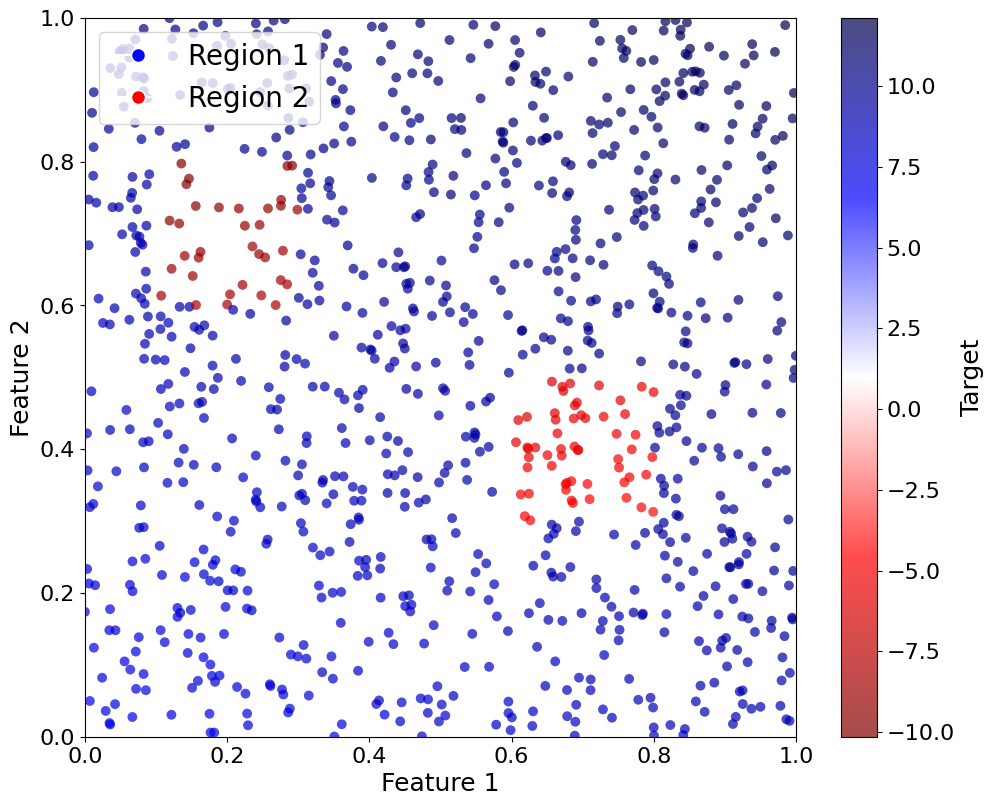

In [ ]:
plt.figure(figsize=(10, 8))

sc = plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], c=y_ex, cmap='seismic_r', alpha=0.7, edgecolors='none', s=50)
plt.colorbar(sc, label='Target')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout(pad=0.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor='blue', markersize=10, label='Region 1'),
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor='red', markersize=10, label='Region 2')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=20)

# plt.savefig('images/synthetic_dataset.pdf', dpi=300)
plt.show()

## Baseline

In [206]:
def split_and_transform(X: pd.DataFrame, y: pd.DataFrame):
    scalers = {'scaler_X': MinMaxScaler(), 'scaler_y': MinMaxScaler(), 'ord_encoder': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)}
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    X_train, X_test, y_train, y_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True), y_train.reset_index(drop=True), y_test.reset_index(drop=True)
    
    X_train = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train))
    X_test = pd.DataFrame(scalers['scaler_X'].transform(X_test))
    y_train = pd.DataFrame(scalers['scaler_y'].fit_transform(y_train.values.reshape(-1, 1)))
    y_test = pd.DataFrame(scalers['scaler_y'].transform(y_test.values.reshape(-1, 1)))
        
        
    return X_train, X_test, y_train, y_test, scalers


def train_model(model_type, X_train, y_train):
    model = model_type
    model.fit(X_train, y_train)
    
    return model


def evaluate_model(model_type, X, y):
    metrics = {'mse': [], 'r2': [], 'mape': []}
    
    for _ in range(31):
        X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
        model = train_model(model_type, X_train, y_train)
        
        prediction = model.predict(X_test)
    
        metrics['mse'].append(mean_squared_error(y_test.values, prediction))
        metrics['r2'].append(r2_score(y_test.values, prediction))
        metrics['mape'].append(mean_absolute_percentage_error(y_test.values, prediction))
    
    metrics_df = pd.DataFrame([[np.mean(metrics['mse']), np.std(metrics['mse'])],
                               [np.mean(metrics['r2']), np.std(metrics['r2'])],
                               [np.mean(metrics['mape']), np.std(metrics['mape'])]], columns=['MEAN', 'STD'], index=['mse', 'r2', 'mape'])
        
    return metrics_df.round(3)

In [207]:
X_train, X_test, y_train, y_test, scalers = split_and_transform(X_ex, y_ex)

In [208]:
baseline_model = train_model(LinearRegression(), X_train, y_train)
new_model = train_model(XGBRegressor(), X_train, y_train)

In [209]:
baseline_prediction = baseline_model.predict(X_test).flatten()

In [210]:
evaluate_model(XGBRegressor(), X_ex, y_ex)

,MEAN,STD
mse,0.005,0.004
r2,0.907,0.072
mape,0.154,0.156


## Select bad examples

In [237]:
def select_bad_examples(X: pd.DataFrame, y: pd.DataFrame, predictions: np.array, thrs: float = 0.05):
    idx_bad = np.where(np.abs(y.values.flatten() - predictions.flatten()) >= thrs)[0]
    bad_y = y.iloc[idx_bad]
    bad_X = X.iloc[idx_bad]
    
    return bad_X, bad_y

In [238]:
bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, 0.2)

In [239]:
(len(bad_X) / len(X_test)) * 100

11.5

In [240]:
bad_X.shape

(23, 2)

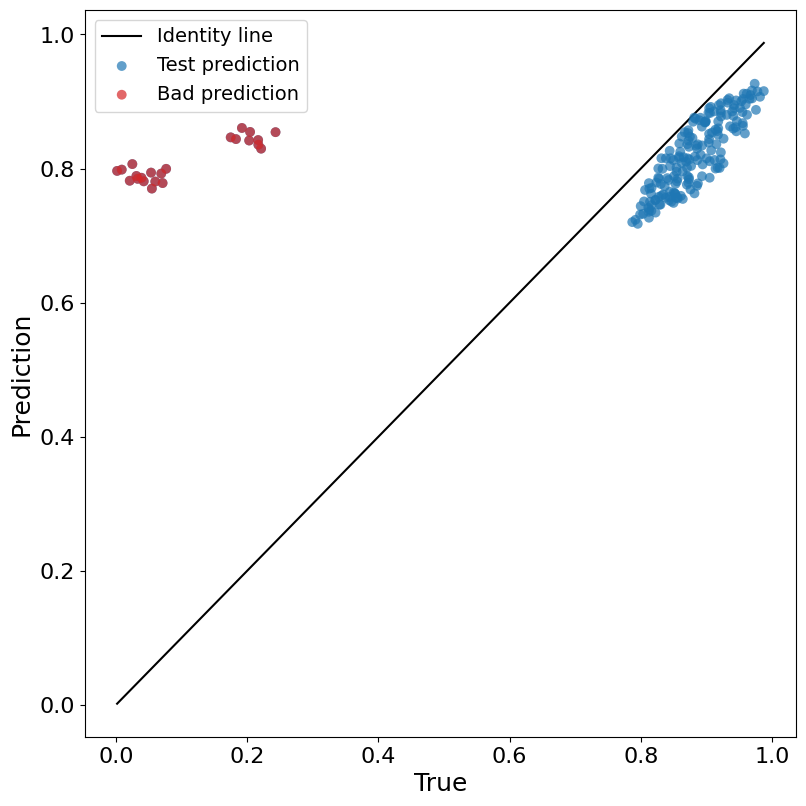

In [241]:
plt.figure(figsize=(8, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(y_test.values, baseline_prediction, color='tab:blue', alpha=0.7, label='Test prediction', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y, baseline_model.predict(bad_X), color='tab:red', alpha=0.7, label='Bad prediction', zorder=3, edgecolors='none', s=50)

plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_bad_moscow_0_3.pdf', dpi=300)
plt.show()

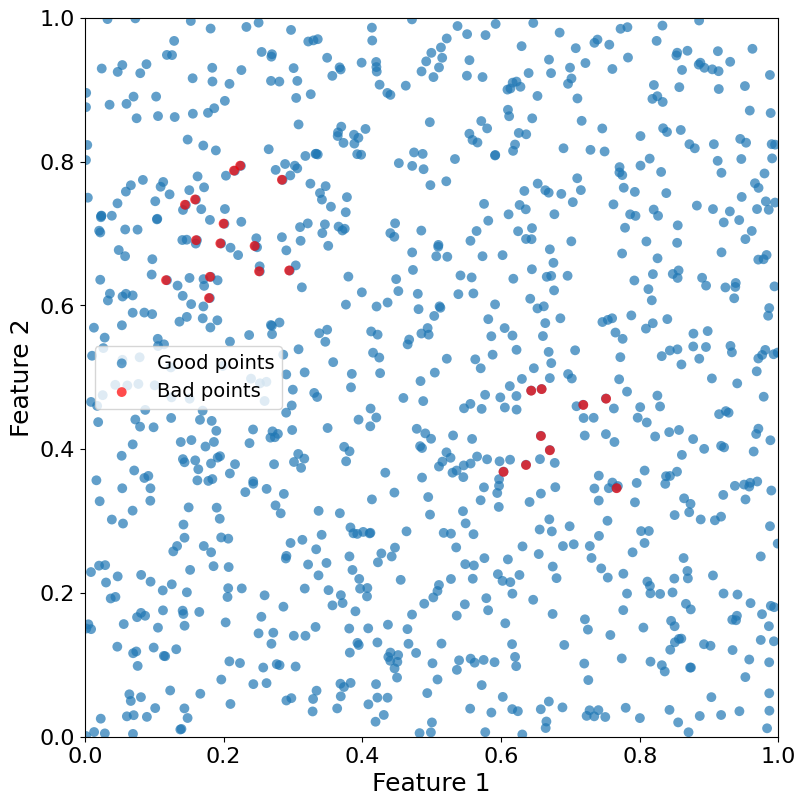

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/bad_X.pdf', dpi=300)
plt.show()

In [242]:
def custom_crossover_num(ind1, ind2, num_eta=10):
    num1_copy = copy.deepcopy(ind1)
    num2_copy = copy.deepcopy(ind1)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1 = num1_copy
    ind2 = num2_copy

    return ind1, ind2

In [243]:
def custom_mutate_num(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate # * weights[i]
        
        if random.random() < mutation_prob:
            coef = linear_coefs[i]
            direction = 1 if coef * target_direction >= 0 else -1
            
            # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
            noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
            individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,

In [244]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train.values, y_train.values)
linear_coefs = lr.coef_[0]

In [245]:
def augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps: int = 10):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()

    if (length_dict['length_cat_ordinal'] == 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return creator.Individual(np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])]))
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num)
            
            
    elif (length_dict['length_cat_ordinal'] != 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(len(cat_columns)):
            toolbox.register(f"cat_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        for i in range(length_cat_ordinal, length_cat_ordinal + length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i - length_cat_ordinal}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
                [toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])])
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num_ord)
        
        
    else:
        return 0
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
        
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
            
        # for i in range(length_num):
        #     # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        #     toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        # def make_individual():
        #     return 0
            
        # toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        # toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        # toolbox.register("mate", custom_crossover_num_ord_nominal)
        
        


    # def make_individual():
    #     if (length_cat_ordinal == 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     elif (length_cat_ordinal != 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
    #             [toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     else:
    #         return 0

    toolbox.register("select", tools.selTournament, tournsize=3)
    
    steps = tqdm(range(len(bad_X)))
    best_individuals = []
    bad_y_sc_arr = []
    prediction_exp = baseline_model.predict(bad_X)
    
    

    for _ in range(num_steps):
        bad_y_scenario = np.maximum(np.minimum(0.0, y_test.min().values[0]),
                                    np.minimum(bad_y + np.random.normal(0, 0.01, (len(bad_y), 1)), np.maximum(1.0, y_test.max().values[0])))
        # bad_y_scenario = bad_y
        
        for i in steps:
            def eval_func(individual, y_target, linear_coefs, weights, target_direction, bonus_factor = 0.9):
                prediction = baseline_model.predict([individual])
                error = 0.5 * (prediction[0] - y_target.values[i])**2 - np.mean( (individual - bad_X.values[i])**2 )
                # bonus = 0
                # for k, val in enumerate(individual):
                #     # if k > len(cat_cols_name):
                #         coef = linear_coefs[k]
                #         base_val = X_exp.loc[idx_sc].iloc[i, k+1]
                        
                
                #         if coef * target_direction >= 0:  # Увеличение признака повышает таргет
                #             if val > base_val:
                #                 bonus += weights[k] * (val - base_val) * bonus_factor
                #         elif coef * target_direction < 0:  # Уменьшение признака повышает таргет
                #             if val < base_val:
                #                 bonus += weights[k] * (base_val - val) * bonus_factor
                                
                total_fitness = error #+ bonus
                return (total_fitness,)
            
            def main(target_direction, y_target):
                toolbox.register("evaluate", eval_func, y_target=y_target, 
                                linear_coefs=linear_coefs, weights=1, target_direction=target_direction)
                # toolbox.unregister("mutate")
                if length_dict['length_cat_ordinal'] == 0:
                    toolbox.register("mutate", custom_mutate_num, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)
                else:
                    toolbox.register("mutate", custom_mutate_num_ord, bad_X=bad_X, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)

                pop = toolbox.population(n=30)
                hof = tools.HallOfFame(1, similar=np.array_equal)
                stats = tools.Statistics(lambda ind: ind.fitness.values)
                stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
                stats.register("max", lambda x: max(i[0] for i in x))

                algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
                
                return hof[0]
        
            if bad_y_scenario.values[i] >= prediction_exp[i]:
                target_direction = 1
            else:
                target_direction = -1
            
            
            best_individual = main(target_direction, bad_y_scenario)
            best_individuals.append(best_individual)
            
        bad_y_sc_arr.append(bad_y_scenario.values.flatten())
        
    bad_y_sc_arr = np.hstack(bad_y_sc_arr)
    best_individuals = np.array(best_individuals)
    
    return best_individuals, bad_y_sc_arr

In [246]:
best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=10)

100%|██████████| 23/23 [00:00<00:00, 113.86it/s]


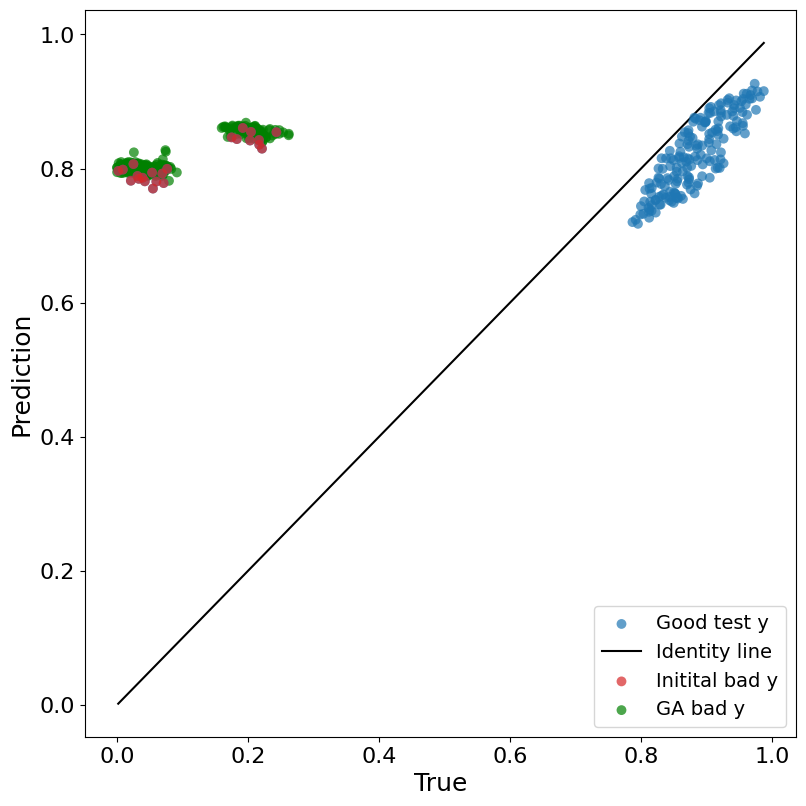

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(y_test.values, baseline_prediction, color='tab:blue', alpha=0.7, label='Good test y', zorder=3, edgecolors='none', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(bad_y, baseline_model.predict(bad_X), alpha=0.7, label='Initital bad y', color='tab:red', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y_sc_arr, baseline_model.predict(best_individuals), alpha=0.7, label='GA bad y', color='green', edgecolors='none', s=50)


plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
# plt.ylim((y_test.min().values - 0.01, 0.6))
# plt.xlim((y_test.min().values - 0.01, 0.6))

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_best_ind.pdf', dpi=300)
plt.show()

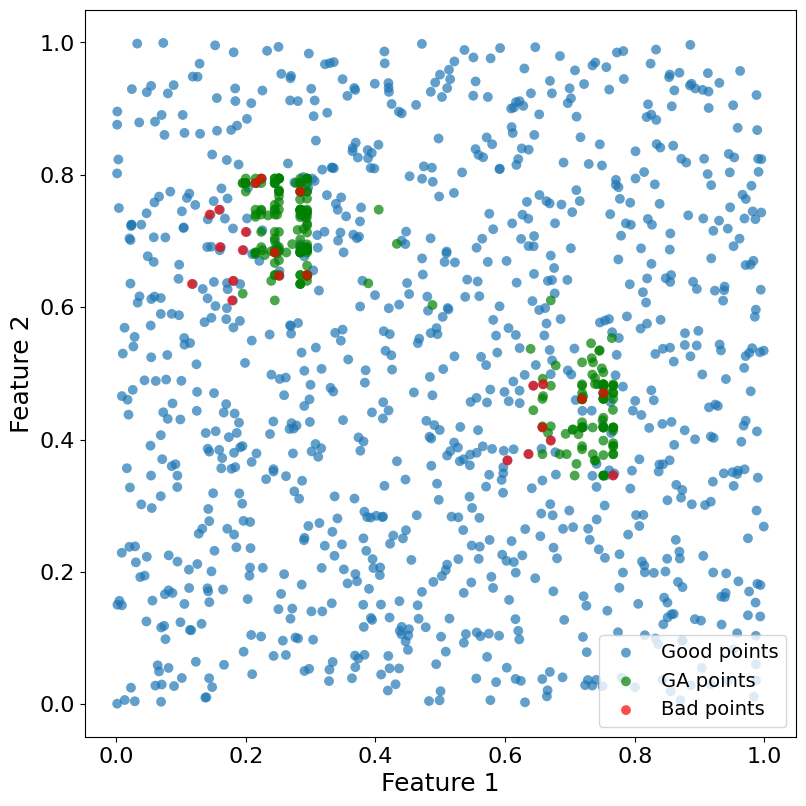

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/GA_points.pdf', dpi=300)
plt.show()

In [249]:
y_test.min().values

array([0.00170756])

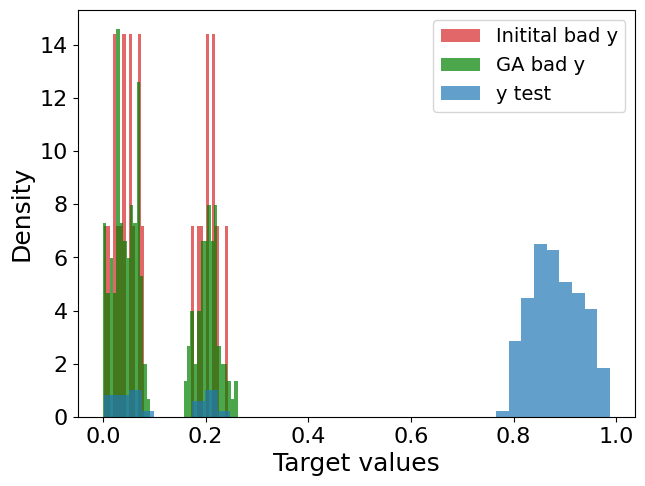

In [250]:
plt.hist(bad_y, bins=40, density=True, alpha=0.7, label='Initital bad y', color='tab:red')
plt.hist(bad_y_sc_arr, bins=40, density=True, alpha=0.7, label='GA bad y', color='green')
plt.hist(y_test, bins=40, density=True, alpha=0.7, label='y test', color='tab:blue')


plt.legend()
plt.xlabel('Target values')
plt.ylabel('Density')

plt.tight_layout(pad=0.5)
# plt.savefig('images/hist_ga_moscow_0_1.pdf', dpi=300)
plt.show()

In [ ]:
bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), baseline_model.predict(best_individuals), 0.2)

In [252]:
idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
np.random.shuffle(idx_rnd)

augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]

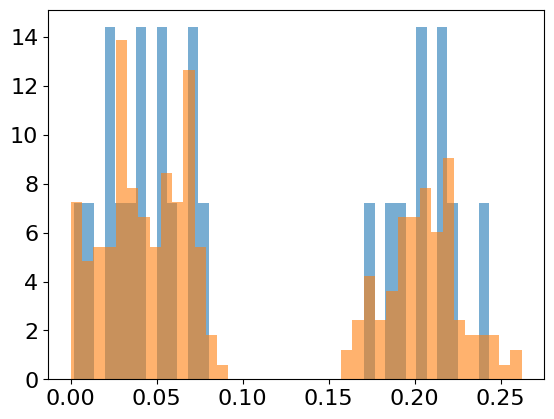

In [253]:
# plt.hist(y_test, density=True, alpha=0.6, bins=40)
plt.hist(bad_y, density=True, alpha=0.6, bins=40)
plt.hist(augmented_y, bins=40, density=True, alpha=0.6)
plt.show()

In [254]:
augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)

In [255]:
augmented_data.shape

(253, 3)

## Generator

In [256]:
# scaler = MinMaxScaler()
# bad_data = scaler.fit_transform(bad_data)
data_tensor = np.array(augmented_data).astype('float32')
data_tensor = torch.tensor(data_tensor)

In [257]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.act(out)
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.act(out)
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32, cat_cardinalities: list = []):
        super(VAE, self).__init__()
        
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels
        self.act = nn.SiLU()
        
        
        
        if not cat_cardinalities:
            self.cat_flag = False
            self.h_dim_enc = seq_length * hidden_channels
            self.decoder_reshape_dim = self.seq_length
            self.n_cat = 0
            self.h_dim_dec = 2**9
            self.decoder_reshape_dim = self.h_dim_dec // self.hidden_channels
            
            self.proj = nn.Sequential(nn.Linear(self.decoder_reshape_dim, 2**6),
                                  self.act,
                                  nn.Linear(2**6, 2**6),
                                  self.act,
                                  nn.Linear(2**6, self.seq_length))
            
        else:
            self.cat_flag = True
            self.emb_dim = 4
            self.n_cat = len(cat_cardinalities)
            self.h_dim_dec = 2**9
            # self.decoder_reshape_dim = (self.h_dim_dec + (self.emb_dim - 1) * self.n_cat)
            self.decoder_reshape_dim = self.h_dim_dec // self.hidden_channels
            self.cat_heads = nn.ModuleList([nn.Linear(self.emb_dim - 1, card) for card in cat_cardinalities])

            # self.decoder_with_logit_dim = 
            
            self.embeddings = []
            for card in cat_cardinalities:
                self.embeddings.append(nn.Embedding(card, self.emb_dim))
                
            self.h_dim_enc = (seq_length + (self.emb_dim - 1) * self.n_cat) * hidden_channels 
            
            self.proj = nn.Sequential(nn.Linear(self.decoder_reshape_dim - (self.emb_dim - 1) * self.n_cat, 2**6),
                                  self.act,
                                  nn.Linear(2**6, 2**6),
                                  self.act,
                                  nn.Linear(2**6, self.seq_length - self.n_cat))
        

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        # self.fc_mu = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        # self.fc_logvar = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_dec))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        
        
        self.condition_encoder_beta = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        self.condition_encoder_gamma = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        # self.condition_decoder_beta = nn.Sequential(
        #     nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
        #     self.act,
        #     nn.Linear(1, 2**6),
        #     self.act,
        #     nn.Linear(2**6, self.seq_length + self.emb_dim - 1),
        #     self.act
        # )
        
        # self.condition_decoder_gamma = nn.Sequential(
        #     nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
        #     self.act,
        #     nn.Linear(1, 2**6),
        #     self.act,
        #     nn.Linear(2**6, self.seq_length + self.emb_dim - 1),
        #     self.act
        # )
        
        self.condition_decoder_beta = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.decoder_reshape_dim),
            self.act
        )
        
        self.condition_decoder_gamma = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.decoder_reshape_dim),
            self.act
        )
        
        
            
        # if self.cat_flag:
            # self.embedding = nn.Embedding(len(scalers['ord_encoder'].categories_[0]), 2)

        
    
        # self.decoder_proj = nn.Linear(self.decoder_reshape_dim, )
        

    def encode(self, x, y):
        # x: (B, 1, T), y: (B, 1, 1)
        if self.cat_flag:
            emb_list = []
            for i, emb in enumerate(self.embeddings):
                emb_list.append(emb(x[:,:,i].long()))
            emb_list = torch.cat(emb_list, dim=2)
            
            x = torch.cat([x[:,:, self.n_cat:], emb_list], dim=2) #(B, 1, T + (emb_dim - 1) * n_cat)
            
        
        x = self.enc_conv1(x)
        x = self.act(x)
        x = self.enc_res1(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
        
        x = self.enc_conv2(x)
        x = self.act(x)
        x = self.enc_res2(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
  
        x = x.view(x.size(0), -1) #(B, hidden_channels * (T + (emb_dim - 1) * n_cat))
        
        mu = self.fc_mu(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1) #(B, latent_dim)
        logvar = self.fc_logvar(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1) #(B, latent_dim)
        
        return mu, logvar
    

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


    def decode(self, z, y):
        # z: (B, latent_dim), y: (B, 1, 1)
        
        x = self.fc_decode(z) #(B, h_dim_dec)
        x = x.view(z.size(0), self.hidden_channels, self.decoder_reshape_dim) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.dec_conv1(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.act(x)
        x = self.dec_res1(x)
        x = self.dec_conv2(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        
        x = self.dec_res2(x) * self.condition_decoder_beta(y) + self.condition_decoder_gamma(y)
        x = self.dec_conv3(x) #(B, 1, h_dim_dec//hidden_channel)
        
        if self.cat_flag:
            x_cat, x_num = x[:,:, :(self.emb_dim - 1) * self.n_cat], x[:,:, (self.emb_dim - 1) * self.n_cat:] 
            #x_cat: (B, 1, (emb_dim - 1) * n_cat), x_num: (B, 1, T - (emb_dim - 1) * n_cat)
            cat_logits = [head(x_cat) for head in self.cat_heads] if self.n_cat > 0 else []

            x_num = self.proj(x_num) #(B, 1, T - n_cat)
        
        else:
            x_num = self.proj(x)
            cat_logits = []
        
        return x_num, cat_logits
    

    def forward(self, x):
        x, y = x[:,:,:-1], x[:,:,-1].unsqueeze(1)
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x_num, recon_x_logits = self.decode(z, y)
        
        return recon_x_num, recon_x_logits, mu, logvar
    

def vae_loss(recon_x_num, recon_x_logits, x, mu, logvar, beta, cat_target_flag=False):
    if cat_target_flag:
        recon_num = F.mse_loss(recon_x_num, x[:,:, length_dict['length_cat_ordinal']:-1], reduction='mean')
      
        x_cat = x[:, :, :length_dict['length_cat_ordinal']].squeeze(1).long().transpose(0, 1)

        # Categorical cross-entropy
        recon_cat = torch.tensor(0.0, device=device)
        recon_x_logits = recon_x_logits
     
        cat_losses = []
        for logits, tgt in zip(recon_x_logits, x_cat):
            # logits: [B, card], tgt: [B]
            cat_losses.append(F.cross_entropy(logits.squeeze(1), tgt, reduction='mean'))
        recon_cat = torch.stack(cat_losses).sum()
            
        recon_loss = recon_num + 0.1 * recon_cat
        
    else:
        recon_loss = F.mse_loss(recon_x_num, x[:,:, :-1], reduction='mean')

    
    # kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
    return recon_loss + beta * kl_loss

In [279]:
def train_vae(data_tensor, num_epochs = 200, learning_rate = 1e-3, batch_size = 2**6, input_channels = 1, cat_target_flag = True):
    seq_length = data_tensor.size(1) - 1
    train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1), batch_size=batch_size, shuffle=True)

    model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=16)
    model_vae.to(device)
    optimizer = optim.AdamW(model_vae.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.001, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model_vae.train()
    
    for epoch in epochs:
        epoch_loss = 0
        
        for _, data in enumerate(train_loader):
            data = data.to(device)
            
            recon_x_num, recon_x_logits, mu, logvar = model_vae(data)
            loss = vae_loss(recon_x_num, recon_x_logits, data, mu, logvar, beta_sch[epoch], cat_target_flag)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model_vae.parameters(), max_norm=3)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
     
        if epoch % 2 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}, LR: {round(optimizer.param_groups[0]["lr"], 4)}')
            
    return model_vae, losses

In [280]:
model_vae, losses = train_vae(data_tensor, cat_target_flag=False)

Average Loss: 0.0001, LR: 0.0001: 100%|██████████| 200/200 [00:20<00:00,  9.73it/s]


In [281]:
seq_length = len(augmented_data[0]) - 1
input_channels = 1
sum([p.numel() for p in model_vae.parameters()]) / 1e6

0.202019

In [282]:
# from torchsummary import summary
# summary(model_vae, input_size=(1, seq_length + 1))

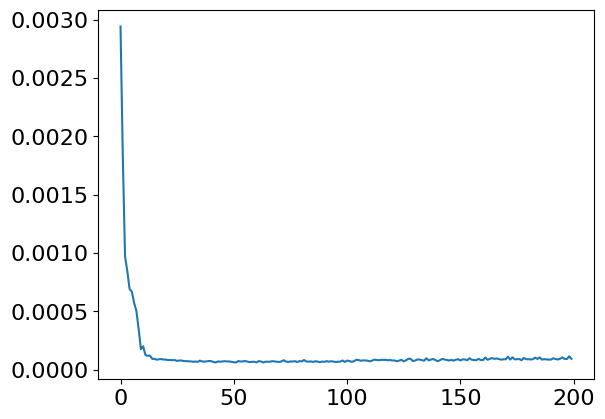

In [283]:
plt.plot(losses[:])
plt.show()

In [284]:
def generate(model, data_tensor, mult: int = 5) -> np.array:
    synth_vae_arr = []

    for _ in range(mult):
        
        if CAT_FLAG:
            synth_vae_num, synth_vae_logits, _, _ = model(data_tensor.unsqueeze(1).to(device))
            synth_vae_num = synth_vae_num.squeeze(1).detach().cpu().numpy()
            
            cat_arr = []
            for logits in synth_vae_logits:
                cat_arr.append(logits.squeeze(1).softmax(dim=-1).argmax(dim=-1).long().view(-1, 1).detach().cpu().numpy())
            cat_arr = np.hstack(np.array(cat_arr))
            
            synth_vae = np.concatenate([cat_arr, synth_vae_num], axis=1)
            
            synth_vae_arr.append(synth_vae)
        
        else:
            synth_vae_num, synth_vae_logits, _, _ = model(data_tensor.unsqueeze(1).to(device))
            synth_vae_num = synth_vae_num.squeeze(1).detach().cpu().numpy()
            synth_vae_arr.append(synth_vae_num)
        
        
    synth_vae = np.vstack(np.array(synth_vae_arr))
    
    return synth_vae #(5*N, T)

In [285]:
model_vae.eval()

VAE(
  (act): SiLU()
  (proj): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (enc_conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_res1): ResidualBlock(
    (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
    (drop1): Dropout(p=0.1, inplace=False)
    (drop2): Dropout(p=0.1, inplace=False)
  )
  (enc_conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn2): BatchNorm1d(16, eps=1e

In [286]:
synth_vae = generate(model_vae, data_tensor)
synth_vae.shape

(1265, 2)

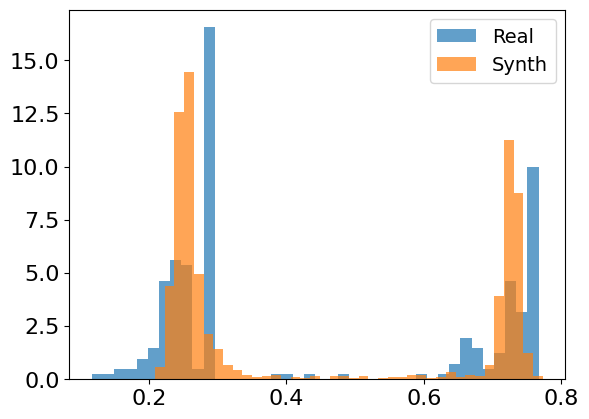

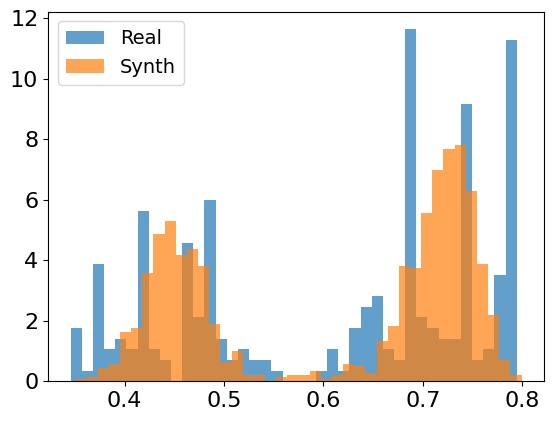

In [287]:
for i in range(2):
    plt.hist(augmented_data[:, i], bins=40, alpha=0.7, density=True, label='Real')
    plt.hist(synth_vae[:, i], bins=40, alpha=0.7, density=True, label='Synth')

    plt.legend()
    plt.show()

In [288]:
# synth_df = pd.DataFrame(np.concatenate([scaler_X_train.inverse_transform(synth_vae[:, :-1]), scaler_y_train.inverse_transform(synth_vae[:, -1].reshape(-1, 1))], axis=1), columns=data.columns)
# synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae), scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(5).reshape(-1, 1))], axis=1))
synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))

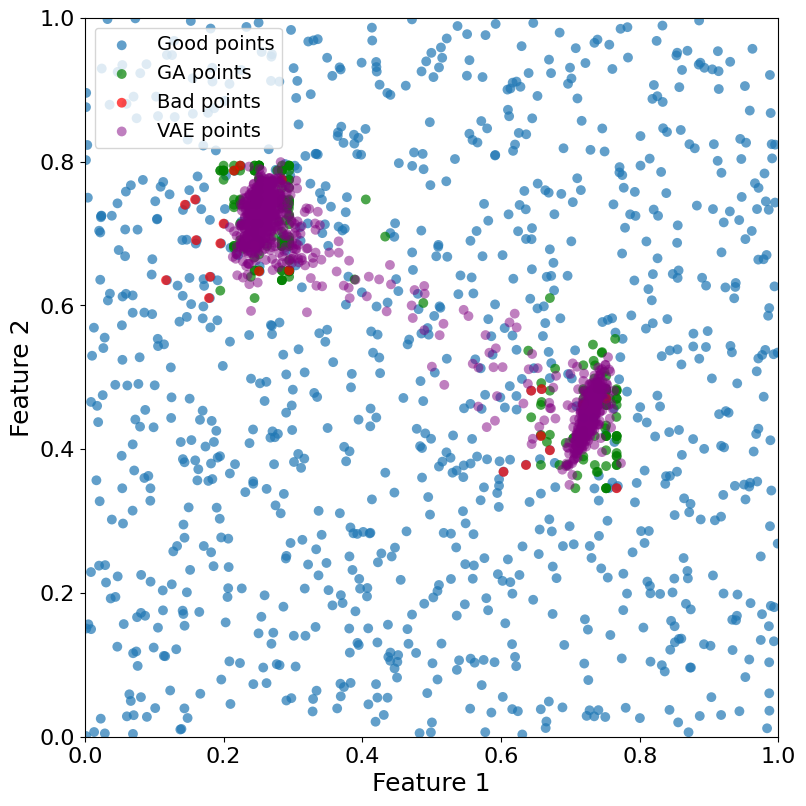

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')
plt.scatter(synth_df.iloc[:, 0], synth_df.iloc[:, 1], color='purple', alpha=0.5, edgecolors='none', s=50, label='VAE points')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/VAE_points.pdf', dpi=300)
plt.show()

In [290]:
# bad_data['pricemetr'].hist(bins=40,  alpha=0.7, density=True)
# synth_df['pricemetr'].hist(bins=40, alpha=0.7, density=True)

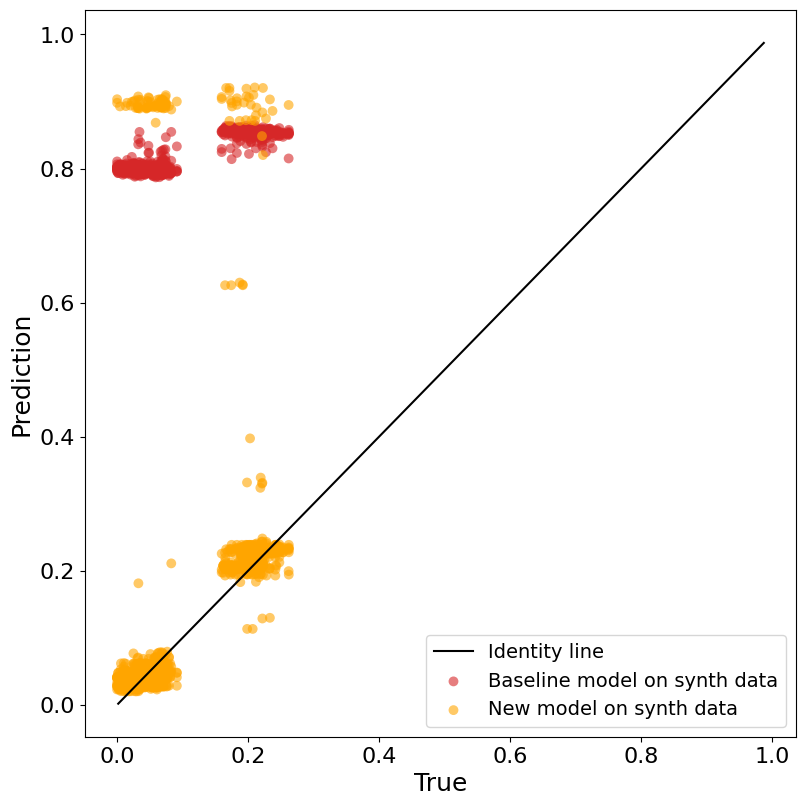

In [ ]:
plt.subplots(figsize=(8, 8))
# synth_pred = xgb.predict(synth_df.drop('pricemetr', axis=1))
X_tilde = synth_df.iloc[:, :-1]
X_tilde.columns = X_train.columns

synth_pred = baseline_model.predict(X_tilde)
new_model_synth_pred = new_model.predict(X_tilde)

# plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.6, label='Real bad X', color='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Baseline model on augmented data', color='tab:green', edgecolors='none', s=50)
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='New model on augmented data', color='orange', edgecolors='none', s=50)
plt.scatter(synth_df.iloc[:, -1], synth_pred, alpha=0.6, label='Baseline model on synth data', color='tab:red', edgecolors='none', s=50)
plt.scatter(synth_df.iloc[:, -1], new_model_synth_pred, alpha=0.6, label='New model on synth data', color='orange', edgecolors='none', s=50)


plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/vae_prediction.pdf', dpi=300)
plt.show()

In [272]:
mean_squared_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))

(0.5143115385587109, 0.03527137489783838)

In [273]:
mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))

(0.499883436395044, 8.515557416647459e-05)

In [274]:
mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())

(0.5142905138245196, 0.0428885854780674)

In [25]:
from scipy.stats import wasserstein_distance

def smape(A, F):
    return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F) + np.finfo(float).eps))

In [ ]:
def experiment(X: pd.DataFrame, y: pd.DataFrame, baseline_model, new_model,
               num_trials: int = 31,
               alpha: float = 0.1,
               exp_num = '1',
               batch_size=127,
               num_steps=10,
               num_epochs=100):
    
    eval_metrics = {'mse_aug_b': [], 'mse_bad_b': [], 'mse_synth_b': [],
                    'mse_aug_n': [], 'mse_bad_n': [], 'mse_synth_n': [],
                    'mape_aug_b': [], 'mape_bad_b': [], 'mape_synth_b': [],
                    'mape_aug_n': [], 'mape_bad_n': [], 'mape_synth_n': [],
                    'r2_aug_b': [], 'r2_bad_b': [], 'r2_synth_b': [],
                    'r2_aug_n': [], 'r2_bad_n': [], 'r2_synth_n': [],
                    'wd': []}
    
 

    length_dict = {'length_cat_ordinal': 0, 'length_cat_onehot': [], 'length_num': 2}
    
    
    for i in range(num_trials):
        try:
            X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
            baseline_model = train_model(baseline_model, X_train, y_train)
            new_model = train_model(new_model, X_train, y_train)
            baseline_prediction = baseline_model.predict(X_test).flatten()
            
            bad_X, bad_y = select_bad_examples(X_test, y_test,
                                               baseline_prediction,
                                               alpha)
            
            lr = LinearRegression(fit_intercept=False)
            lr.fit(X_train.values, y_train.values)
            linear_coefs = lr.coef_[0]
            
  
            best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=num_steps)
            
            bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr),
                                                     baseline_model.predict(best_individuals),
                                                     alpha)
            
            idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
            np.random.shuffle(idx_rnd)

            augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
            augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]
            augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)
            
            
            data_tensor = np.array(augmented_data).astype('float32')
            data_tensor = torch.tensor(data_tensor)
            
            model_vae, _ = train_vae(data_tensor, num_epochs=num_epochs, batch_size=batch_size, cat_target_flag=CAT_FLAG)
            model_vae.eval()
            
            synth_vae = generate(model_vae, data_tensor)
            # synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae),
                                                    # scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(10).reshape(-1, 1))], axis=1))
            wd = np.mean(list(map(lambda x, y: wasserstein_distance(x, y), synth_vae.T, augmented_data.T)))
            eval_metrics['wd'].append(wd)
                                                    
            synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))
            
            # synth_pred = baseline_model.predict(synth_df.drop(2, axis=1))
            # new_model_synth_pred = new_model.predict(synth_df.drop(2, axis=1))
            
            X_tilde = synth_df.iloc[:, :-1]
            X_tilde.columns = X_train.columns

            synth_pred = baseline_model.predict(X_tilde)
            new_model_synth_pred = new_model.predict(X_tilde)
            
            np.savez(f'Checkpoints/baseline_pred_exp{exp_num}_iter_{i+1}.npz', bad=baseline_model.predict(bad_X).flatten(), aug=baseline_model.predict(augmented_X).flatten(), synth=synth_pred.flatten())
            np.savez(f'Checkpoints/new_model_pred_exp{exp_num}_iter_{i+1}.npz', bad=new_model.predict(bad_X).flatten(), aug=new_model.predict(augmented_X).flatten(), synth=new_model_synth_pred.flatten())
            np.savez(f'Checkpoints/data_exp{exp_num}_iter_{i+1}.npz', bad=bad_y.values.flatten(), aug=augmented_y.flatten(), synth=data_tensor[:, -1].repeat(5).numpy().flatten())
            
            
            
            mse_aug_b = mean_squared_error(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            mse_bad_b = mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            mse_synth_b = mean_squared_error(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            mse_aug_n = mean_squared_error(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            mse_bad_n = mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            mse_synth_n = mean_squared_error(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            
            mape_aug_b = smape(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            mape_bad_b = smape(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            mape_synth_b = smape(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())

            mape_aug_n = smape(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            mape_bad_n = smape(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            mape_synth_n = smape(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
        

            # mape_aug = mean_absolute_percentage_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # mape_bad = mean_absolute_percentage_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # mape_synth = mean_absolute_percentage_error(data_tensor[:, -1].repeat(10).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(10).numpy(), new_model_synth_pred.flatten())
            
            # r2_aug = r2_score(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # r2_bad = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # r2_synth = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
            
            r2_aug_b = r2_score(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            r2_bad_b = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            r2_synth_b = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            r2_aug_n = r2_score(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            r2_bad_n = r2_score(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            r2_synth_n = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            
        
            
            eval_metrics['mse_aug_b'].append(mse_aug_b)
            eval_metrics['mse_bad_b'].append(mse_bad_b)
            eval_metrics['mse_synth_b'].append(mse_synth_b)
            
            eval_metrics['mse_aug_n'].append(mse_aug_n)
            eval_metrics['mse_bad_n'].append(mse_bad_n)
            eval_metrics['mse_synth_n'].append(mse_synth_n)
            

            eval_metrics['mape_aug_b'].append(mape_aug_b)
            eval_metrics['mape_bad_b'].append(mape_bad_b)
            eval_metrics['mape_synth_b'].append(mape_synth_b)

            eval_metrics['mape_aug_n'].append(mape_aug_n)
            eval_metrics['mape_bad_n'].append(mape_bad_n)
            eval_metrics['mape_synth_n'].append(mape_synth_n)

            
            eval_metrics['r2_aug_b'].append(r2_aug_b)
            eval_metrics['r2_bad_b'].append(r2_bad_b)
            eval_metrics['r2_synth_b'].append(r2_synth_b)
            
            eval_metrics['r2_aug_n'].append(r2_aug_n)
            eval_metrics['r2_bad_n'].append(r2_bad_n)
            eval_metrics['r2_synth_n'].append(r2_synth_n)
            
        except Exception as e:
            print(e)
            continue
        
    np.save(f'Checkpoints/eval_metrics_exp{exp_num}.npy', eval_metrics)
        
    eval_df_baseline = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_b']):.4f}+-{np.std(eval_metrics['mse_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['mse_bad_b']):.4f}+-{np.std(eval_metrics['mse_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['mse_synth_b']):.4f}+-{np.std(eval_metrics['mse_synth_b']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_b']):.4f}+-{np.std(eval_metrics['mape_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['mape_bad_b']):.4f}+-{np.std(eval_metrics['mape_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['mape_synth_b']):.4f}+-{np.std(eval_metrics['mape_synth_b']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_b']):.4f}+-{np.std(eval_metrics['r2_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_b']):.4f}+-{np.std(eval_metrics['r2_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_b']):.4f}+-{np.std(eval_metrics['r2_synth_b']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2', 'wd'])
    
    eval_df_new = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_n']):.4f}+-{np.std(eval_metrics['mse_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['mse_bad_n']):.4f}+-{np.std(eval_metrics['mse_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['mse_synth_n']):.4f}+-{np.std(eval_metrics['mse_synth_n']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_n']):.4f}+-{np.std(eval_metrics['mape_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['mape_bad_n']):.4f}+-{np.std(eval_metrics['mape_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['mape_synth_n']):.4f}+-{np.std(eval_metrics['mape_synth_n']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_n']):.4f}+-{np.std(eval_metrics['r2_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_n']):.4f}+-{np.std(eval_metrics['r2_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_n']):.4f}+-{np.std(eval_metrics['r2_synth_n']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2', 'wd'])
        
    eval_df_baseline.to_csv(f'Checkpoints/eval_df_baseline_exp{exp_num}.csv', header=True, index=True)
    eval_df_new.to_csv(f'Checkpoints/eval_df_new_exp{exp_num}.csv', header=True, index=True)
    
    return eval_df_baseline, eval_df_new

In [54]:
# baseline_model = train_model(LinearRegression(), X_train, y_train)
# new_model = train_model(XGBRegressor(), X_train, y_train)

In [55]:
import warnings
warnings.filterwarnings("ignore")

In [72]:
random.seed(55551)
fun_list = [create_synth_dataset1(1000), create_synth_dataset2(1000), create_synth_dataset3(1000)]

In [73]:
for i in range(len(fun_list)):
    X_ex, y_ex = fun_list[i]
    eval_df_baseline, eval_df_new = experiment(X_ex, y_ex, LinearRegression(), XGBRegressor(),
                                               num_trials=31, alpha=0.1, exp_num=f'_toy_dataset_{i+1}',
                                               batch_size=16, num_steps=20, num_epochs=200)

Average Loss: 0.0003, LR: 0.0001: 100%|██████████| 200/200 [06:12<00:00,  1.86s/it]


In [74]:
len(np.load('Checkpoints/eval_metrics_exp_toy_dataset_1.npy', allow_pickle=True).item()['mape_aug_b'])

31

In [75]:
np.load('Checkpoints/baseline_pred_exp_toy_dataset_3_iter_3.npz')['aug'].shape

(3171,)

In [76]:
np.load('Checkpoints/baseline_pred_exp_toy_dataset_3_iter_1.npz')['bad']

array([0.57910961, 0.80504659, 0.66958753, 0.66012654, 0.6340357 ,
       0.63238612, 0.78628316, 0.46658502, 0.71017775, 0.65923785,
       0.57798603, 0.6384132 , 0.52805059, 0.65147756, 0.68802723,
       0.49070721, 0.79075153, 0.69332297, 0.79775021, 0.5884775 ,
       0.66603514, 0.53330535, 0.52806087, 0.73726405, 0.67161149,
       0.58891721, 0.58463005, 0.76981611, 0.4791957 , 0.5877735 ,
       0.72159487, 0.6766117 , 0.77076966, 0.50432079, 0.52454011,
       0.74575232, 0.69328896, 0.66887549, 0.84686398, 0.50927745,
       0.45833774, 0.73327886, 0.57923989, 0.86923981, 0.57981611,
       0.70950504, 0.49515984, 0.59556066, 0.61699408, 0.49716347,
       0.61336015, 0.52553163, 0.63297683, 0.82265822, 0.47812681,
       0.61321997, 0.79156725, 0.6597746 , 0.71664325, 0.49411164,
       0.77896423, 0.62263034, 0.6902003 , 0.68163891, 0.78212813,
       0.55156327, 0.7806275 , 0.63358339, 0.69052608, 0.80103798,
       0.72470056, 0.70898093, 0.60764257, 0.71728388, 0.64485

In [78]:
# np.load('Checkpoints/data_exp_alpha_2_iter_1.npz')['bad']

In [79]:
# 1 - np.var(np.load('Checkpoints/data_0.npz')['arr_2'] - np.load('Checkpoints/baseline_pred_0.npz')['arr_2']) / np.var(np.load('Checkpoints/data_0.npz')['arr_2'])

In [89]:
pd.read_csv('Checkpoints/eval_df_baseline_exp_toy_dataset_3.csv').to_latex

<bound method NDFrame.to_latex of   Unnamed: 0    AUG, MEAN+STD   BAD, MEAN+STD  SYNTH, MEAN+STD
0        mse   0.1443+-0.0082  0.1133+-0.0073   0.1427+-0.0084
1      smape   0.6312+-0.0320  0.5907+-0.0349   0.6300+-0.0326
2         r2  -0.2606+-0.0562  0.0108+-0.0404  -0.2458+-0.0543
3         wd                -               -   0.0127+-0.0029>

In [90]:
pd.read_csv('Checkpoints/eval_df_new_exp_toy_dataset_3.csv').to_latex

<bound method NDFrame.to_latex of   Unnamed: 0    AUG, MEAN+STD   BAD, MEAN+STD  SYNTH, MEAN+STD
0        mse   0.1525+-0.0153  0.0050+-0.0041   0.1552+-0.0178
1      smape   0.4075+-0.0369  0.0417+-0.0133   0.4131+-0.0424
2         r2  -0.3299+-0.0979  0.9570+-0.0352  -0.3545+-0.1310
3         wd                -               -   0.0127+-0.0029>

In [60]:
np.load('Checkpoints/eval_metrics_exp_alpha_2.npy', allow_pickle=True).item()['mape_synth_n']

[0.4450359429848618,
 0.45714171496449457,
 0.395101172865596,
 0.3594431889993061,
 0.41328082121295284,
 0.44996488764044945,
 0.3633631536832014,
 0.4520695644254788,
 0.38060569324712645,
 0.4257244381294431,
 0.4447086759070625,
 0.36452304074628405,
 0.34756945597546934,
 0.3583976248588326,
 0.4797143143483157,
 0.41223764603415763,
 0.35580604385461106,
 0.35967156370095066,
 0.4065213626620661,
 0.3970267746842972,
 0.38494885667335116,
 0.3665340503110289,
 0.38576944564590543,
 0.307760507382129,
 0.36971579212157657,
 0.38617543818318883,
 0.42290573702937434,
 0.41083556801166876,
 0.4213872263594562]

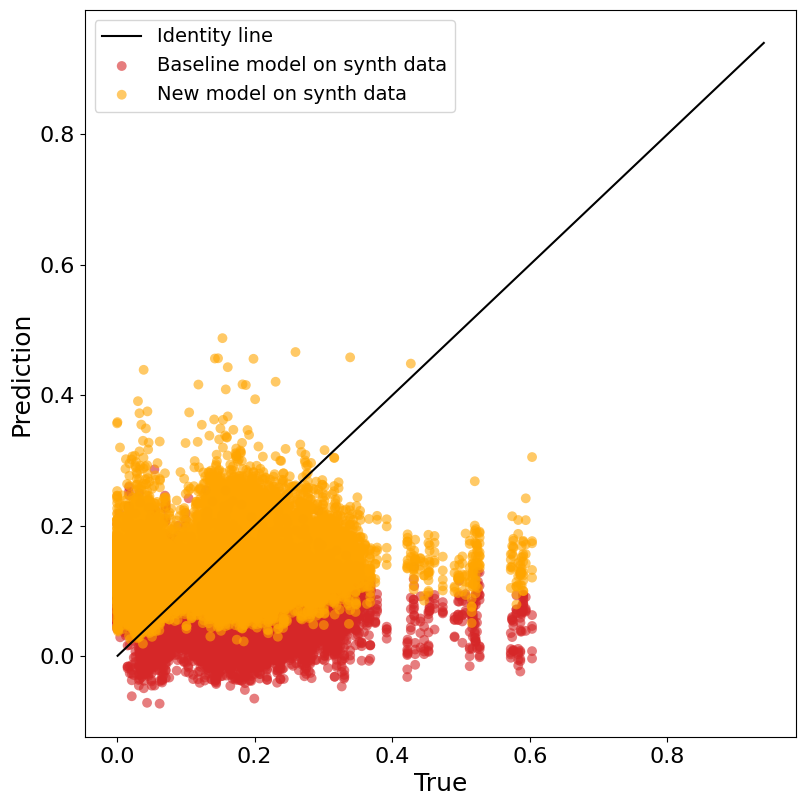

In [33]:
plt.subplots(figsize=(8, 8))

y_tilde = np.load('Checkpoints/data_exp_alpha_1_iter_5.npz')['synth']
synth_pred = np.load('Checkpoints/baseline_pred_exp_alpha_1_iter_5.npz')['synth']
new_model_synth_pred = np.load('Checkpoints/new_model_pred_exp_alpha_1_iter_5.npz')['synth']

# plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.6, label='Real bad X', color='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Baseline model on augmented data', color='tab:green', edgecolors='none', s=50)
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='New model on augmented data', color='orange', edgecolors='none', s=50)
plt.scatter(y_tilde, synth_pred, alpha=0.6, label='Baseline model on synth data', color='tab:red', edgecolors='none', s=50)
plt.scatter(y_tilde, new_model_synth_pred, alpha=0.6, label='New model on synth data', color='orange', edgecolors='none', s=50)


plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/vae_prediction_moscow.pdf', dpi=300)
plt.show()